In [3]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Names from json file:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

# All 561 combinations of coefficients (i.e SM,SM; SM,cQu8; cQu8,cQu8; SM,ctu8; cQu8,ctu8; ...)
name_combinations = []
for i in range(len(names_json)):
    for a in range(i+1):
        name_combinations.append([names_json[i],names_json[a]])

In [5]:
# Open file
file = uproot.open("sample_root_files/output_570.root")
# Open events tree
events_tree = file['Events']
# Open EFTFitCoefficients branch:
eft_coeff = events_tree['EFTfitCoefficients'].array()
jet_pt = events_tree['Jet_pt'].array()

In [6]:
# Making function that adds weights to the histograms below
def weights(data):
    return [1 / len(data)] * len(data)

In [7]:
%%time
# Sneha's Script:
# leptons can be either electron muon or tau. 
# pick two leading leptons and then sum their pt.
# TODO : output an array with the two leading leptons for each event. 

elec_pt = events_tree['Electron_pt'].array()
mu_pt = events_tree['Muon_pt'].array()
tau_pt = events_tree['Tau_pt'].array()

elec_eta = events_tree['Electron_eta'].array()
mu_eta = events_tree['Muon_eta'].array()
tau_eta = events_tree['Tau_eta'].array()

two_leading_leptons = [[]]
for i in range(len(elec_pt)):
    leading_pts, ptlist = [],[]
    ptlist.extend(elec_pt[i])
    ptlist.extend(mu_pt[i]) 
    ptlist.extend(tau_pt[i])
    leading_pts.append(max(ptlist))
    ptlist.remove(max(ptlist))
    leading_pts.append(max(ptlist))
    two_leading_leptons.append(leading_pts)

two_leading_leptons = np.array(two_leading_leptons[1:])

CPU times: user 12.2 s, sys: 15.9 ms, total: 12.3 s
Wall time: 12.3 s


In [8]:
# Separating first and second lepton
first_lepton = two_leading_leptons[:,0]
second_lepton = two_leading_leptons[:,1]

In [9]:
# Making function to get the index (0-560) of the largest coefficient in events with GeV > cutoff 
def eft_coeff_leptons(data, cutoff):
    cut_list = data > cutoff
    eft_coeff_lepton = []
    
    for i,n in enumerate(cut_list):                                       
        if n == True:
            eft_coeff_lepton.append(np.argmax(np.abs(eft_coeff[i][1:])) + 1)
            # +1 since the new list gets shifted by ignoring the first coefficient, but np.argmax doesn't know this...
            
    return(eft_coeff_lepton)

In [10]:
# Running function for first lepton with cutoff at 50 GeV and second lepton with cutoff at 30 GeV
eft_coeff_first_lepton = eft_coeff_leptons(first_lepton, 50)
eft_coeff_second_lepton = eft_coeff_leptons(second_lepton, 30)

In [11]:
def interesting_coeff(data):
    percent_and_index = []
    for i in range(561):
        coeff_percentage = data.count(i) / len(data)
        if coeff_percentage >= 0.01:
            percent_and_index.append([round(coeff_percentage*100), i])
    
           
    percent_and_index = np.array(percent_and_index)
    indices = np.argsort(percent_and_index[:,0])                # This tells me the order of the rows
    percent_and_index_ordered = percent_and_index[indices][::-1] # This sorts the rows based on the indices and [::-1] makes it go in descending order
    
    for i in range(len(percent_and_index_ordered)):
        a = print(f'The pair {name_combinations[percent_and_index_ordered[i,1]]} with index {percent_and_index_ordered[i,1]} has {percent_and_index_ordered[i,0]}%')

    return a

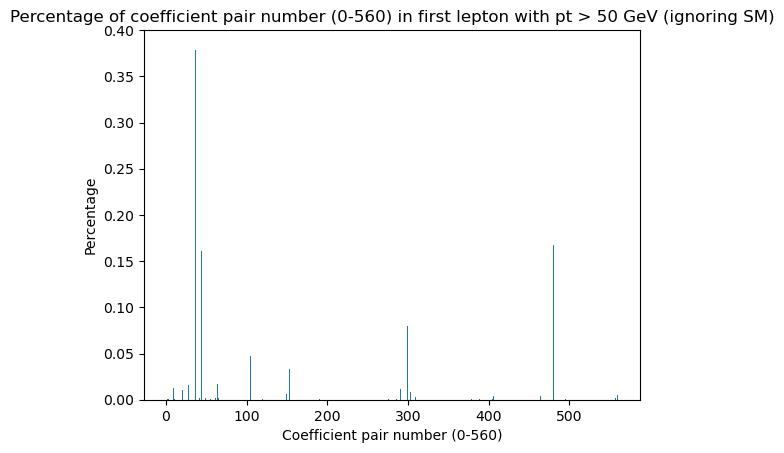

The pair ['ctG', 'SM'] with index 36 has 38%
The pair ['cQq11', 'cQq13'] with index 480 has 17%
The pair ['ctG', 'ctG'] with index 44 has 16%
The pair ['ctq1', 'ctq1'] with index 299 has 8%
The pair ['cbW', 'cbW'] with index 104 has 5%
The pair ['cptb', 'cptb'] with index 152 has 3%
The pair ['ctW', 'ctZ'] with index 64 has 2%
The pair ['cpQ3', 'cpQ3'] with index 27 has 2%
The pair ['ctq1', 'cQq13'] with index 291 has 1%
The pair ['ctu1', 'ctu1'] with index 324 has 1%
The pair ['cpQ3', 'SM'] with index 21 has 1%
The pair ['cQu1', 'cQu1'] with index 9 has 1%


In [12]:
# Plotting histogram for first lepton and also printing the interesting coefficients (higher than 5%)
plt.hist(eft_coeff_first_lepton, bins = 500, weights = weights(eft_coeff_first_lepton))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number (0-560) in first lepton with pt > 50 GeV (ignoring SM)')
plt.ylim(0,0.4)
plt.show()

interesting_coeff(eft_coeff_first_lepton)

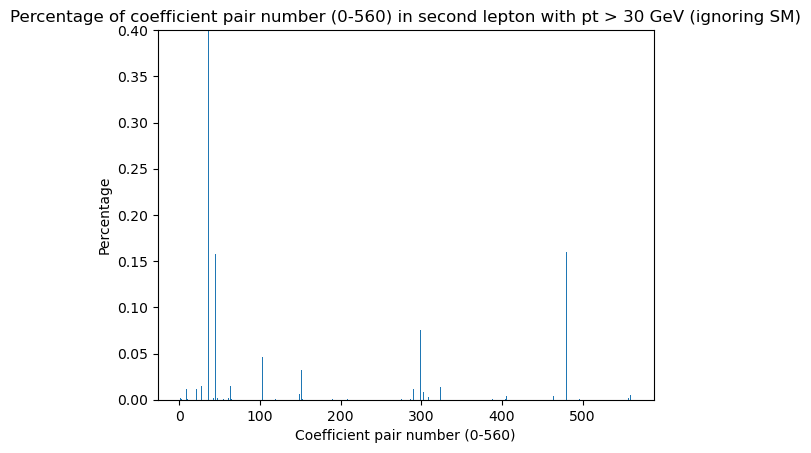

The pair ['ctG', 'SM'] with index 36 has 40%
The pair ['cQq11', 'cQq13'] with index 480 has 16%
The pair ['ctG', 'ctG'] with index 44 has 16%
The pair ['ctq1', 'ctq1'] with index 299 has 8%
The pair ['cbW', 'cbW'] with index 104 has 5%
The pair ['cptb', 'cptb'] with index 152 has 3%
The pair ['ctW', 'ctZ'] with index 64 has 2%
The pair ['cpQ3', 'cpQ3'] with index 27 has 2%
The pair ['ctq1', 'cQq13'] with index 291 has 1%
The pair ['ctu1', 'ctu1'] with index 324 has 1%
The pair ['cpQ3', 'SM'] with index 21 has 1%
The pair ['cQu1', 'cQu1'] with index 9 has 1%


In [13]:
# Plotting histogram for second lepton and also the interesting coefficients (higher than 5%)
plt.hist(eft_coeff_second_lepton, bins = 520, weights = weights(eft_coeff_second_lepton))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number (0-560) in second lepton with pt > 30 GeV (ignoring SM)')
plt.ylim(0,0.4)
plt.show()

interesting_coeff(eft_coeff_second_lepton)

In [14]:
%%time
# My method for the lepton pt and lepton eta!

leading_leptons_pt = []
leading_leptons_eta = []

for i in range(len(elec_pt)):
    lepton_pt = np.concatenate((elec_pt[i],mu_pt[i],tau_pt[i]), axis = 0)         # concatenating all lepton pt and lepton eta
    lepton_eta = np.concatenate((elec_eta[i],mu_eta[i],tau_eta[i]), axis = 0)      
    order = np.argsort(lepton_pt)                                                 # order for values in ascending order
    lepton_pt_sorted = lepton_pt[order]                                           # sorting the lepton pt and lepton eta using the order given above
    lepton_eta_sorted = lepton_eta[order]                                          
    leading_leptons_pt.append([lepton_pt_sorted[-1],lepton_pt_sorted[-2]])        # appending largest values for lepton pt and lepton eta
    leading_leptons_eta.append([lepton_eta_sorted[-1],lepton_eta_sorted[-2]])

leading_leptons_pt = np.array(leading_leptons_pt)
leading_leptons_eta = np.array(leading_leptons_eta)

CPU times: user 1min 16s, sys: 707 ms, total: 1min 17s
Wall time: 1min 17s


In [15]:
print(leading_leptons_eta[10023])
print(f'\n {np.concatenate((elec_pt[10023],mu_pt[10023],tau_pt[10023]), axis = 0)}')
print(f'\n {np.concatenate((elec_eta[10023],mu_eta[10023],tau_eta[10023]), axis = 0)}')

[1.1479492 1.137207 ]

 [68.9, 57.7, 55.6, 24.9, 11.9, 11.6, 4.67, 94, 58.6]

 [1.14, -0.356, 1.31, 0.518, 1.18, 0.474, 0.522, 1.15, -0.355]


In [16]:
# Making sure that both methods give the same results
checking_first_lepton = leading_leptons_pt[:,0] == first_lepton # I defined first_lepton and second_lepton below Sneha's code
checking_second_lepton = leading_leptons_pt[:,1] == second_lepton

print(False in checking_first_lepton)
print(False in checking_second_lepton)

False
False


In [17]:
# Making sure that both methods give the same results
checking_first_lepton = leading_leptons_pt[:,0] == first_lepton # I defined first_lepton and second_lepton below Sneha's code
checking_second_lepton = leading_leptons_pt[:,1] == second_lepton

print(False in checking_first_lepton)
print(False in checking_second_lepton)

False
False


In [18]:
leading_leptons_eta

array([[ 1.126709  ,  1.126709  ],
       [-0.1265564 , -1.2883301 ],
       [-0.9366455 , -0.95214844],
       ...,
       [-1.0209961 , -1.0556641 ],
       [ 1.4943848 ,  1.9116211 ],
       [-0.0027647 , -0.33422852]], shape=(78146, 2), dtype=float32)